In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import pywt
import torch.optim as optim
import glob
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
# 检查CUDA是否可用
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Main_path = 'D:\\Desktop\\Desktop\\Python\\Forward_and_Inverse_problem\\'
Data_path = f'{Main_path}Data\\'
Save_path = f'{Main_path}Nonlinear_verification\\Python_nonlinear_verification2\\'

Using device: cuda:0


In [3]:
M = 9900
A = 1
data = []
labels = []
skipped_files = []  # 记录跳过的文件

# 拿到数据路径，方便后续读取
dir_path = f'{Data_path}Experiment_signal'
dataPaths = sorted(glob.glob(os.path.join(dir_path, '**', '*.csv'), recursive=True))
random.seed(42)
random.shuffle(dataPaths)

# 遍历读取数据
for dataPath in dataPaths:
    # 读取数据（先读取，后验证）
    data_1 = pd.read_csv(dataPath)
    
    # 检查第一列的每一行，找到第一个大于0的值的位置N
    N = 0
    for i in range(len(data_1)):
        if data_1.iloc[i, 1] != 0:
            N = i
            break
    
    # 【关键修复】先验证数据长度，不够就跳过整个文件
    if N >= len(data_1) - M + 1:
        filename = os.path.basename(dataPath)
        print(f"警告：跳过 {filename} - 数据不足(可用{len(data_1)-N}点，需要{M}点)")
        skipped_files.append(filename)
        continue  # 跳过这个文件，data和labels都不添加
    
    # 只有数据足够时，才提取数据和标签
    data.append(data_1.iloc[N:N+M, 1].values)
    
    # 提取标签（移到验证之后）
    filename = os.path.basename(dataPath)
    parts = filename.split('_')
    label1 = float(parts[2])
    label2 = float(parts[3])
    labels.append([label1, label2])

print(f"\n处理完成：成功{len(data)}个，跳过{len(skipped_files)}个")

# 转换为numpy数组
all_datas = np.array(data, dtype="float")
all_labels = np.array(labels)

# 划分数据集（现在不会报错了）
train_datas, temp_datas, train_labels, temp_labels = train_test_split(
    all_datas, all_labels, test_size=0.3, random_state=42
)

validation_datas, test_datas, validation_labels, test_labels = train_test_split(
    temp_datas, temp_labels, test_size=2/3, random_state=42
)

print("训练集数据形状:", train_datas.shape)
print("验证集数据形状:", validation_datas.shape)
print("测试集数据形状:", test_datas.shape)


处理完成：成功864个，跳过0个
训练集数据形状: (604, 9900)
验证集数据形状: (86, 9900)
测试集数据形状: (174, 9900)


In [4]:
train_datas = train_datas.reshape(-1,train_datas.shape[1],1)
validation_datas = validation_datas.reshape(-1,validation_datas.shape[1],1)

print(f'train_datas.shape:{train_datas.shape}')
print(f'validation_datas.shape:{validation_datas.shape}')

train_datas.shape:(604, 9900, 1)
validation_datas.shape:(86, 9900, 1)


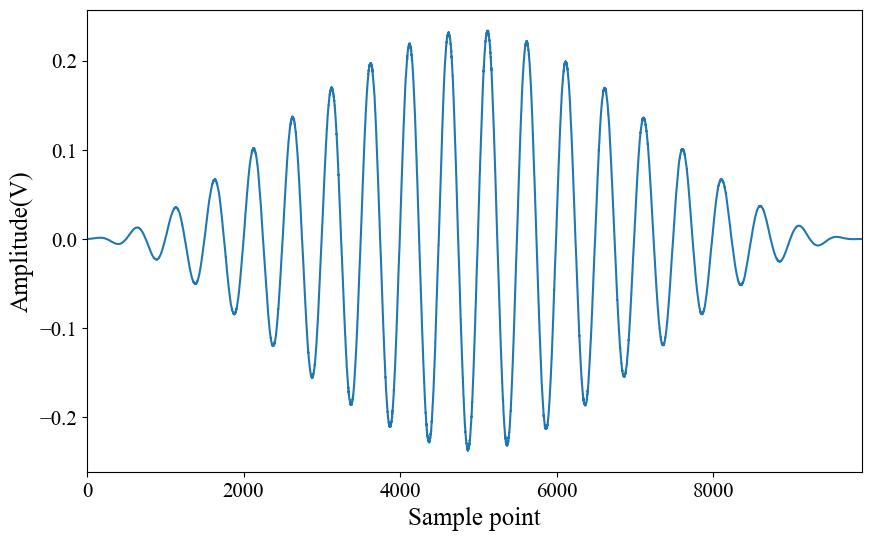

In [5]:
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(train_datas[1],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(V)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置s
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{Save_path}train_signal.jpg', dpi=600, bbox_inches='tight')

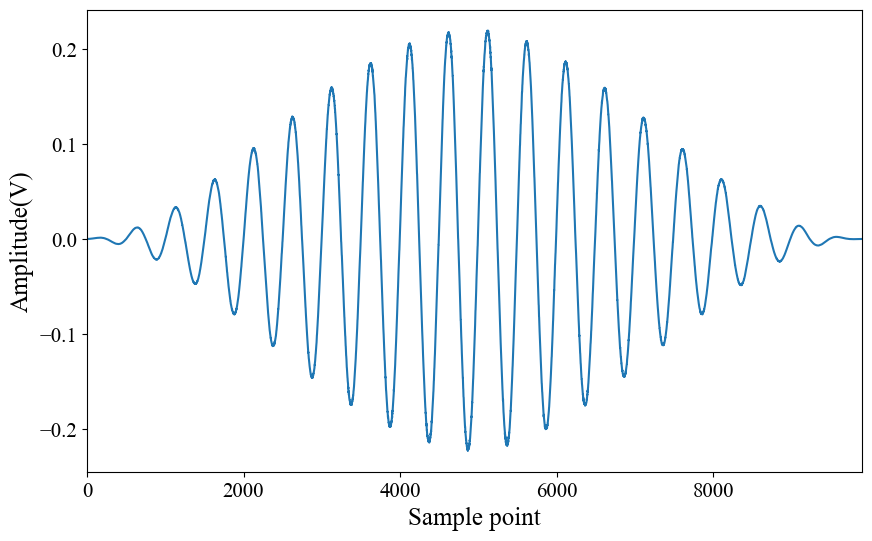

In [6]:
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(validation_datas[1],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(V)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置s
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{Save_path}validation_signal.jpg', dpi=600, bbox_inches='tight')

In [14]:
BATCH_SIZE = 32
input_size = 2480
hidden_size = 64
num_layers = 2
output_size = 2
EPOCH = 1000
learning_rate = 1e-3

In [15]:
# 准备数据
#torch.from_numpy将 NumPy 数组转换为 PyTorch 张量
#TensorDataset用于将张量数据和标签组合成一个数据集
#DataLoader用于从数据集中加载批次数据，并进行训练或测试

train_dataset = TensorDataset(torch.from_numpy(train_datas),torch.from_numpy(train_labels))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

validation_dataset = TensorDataset(torch.from_numpy(validation_datas),torch.from_numpy(validation_labels))
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
class ConvAutoencoderPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate):
        super().__init__()
        self.input_size = input_size
        self.device = device
        
        # ---------- 卷积编码器 ----------
        self.encoder = nn.Sequential(
            nn.Conv1d(input_size, hidden_size*4, 5, stride=2, padding=2),
            nn.BatchNorm1d(hidden_size*4), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Conv1d(hidden_size*4, hidden_size*2, 3, stride=2, padding=1),
            nn.BatchNorm1d(hidden_size*2), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Conv1d(hidden_size*2, hidden_size, 3, stride=1, padding=1),
            nn.BatchNorm1d(hidden_size), nn.ReLU(), nn.Dropout(dropout_rate),
        )

        # ---------- 卷积解码器 ----------
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(hidden_size, hidden_size*2, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(hidden_size*2), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.ConvTranspose1d(hidden_size*2, hidden_size*4, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(hidden_size*4), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.ConvTranspose1d(hidden_size*4, input_size, 5, stride=1, padding=2),
        )

        # ---------- 2 层双向 LSTM ----------
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            bidirectional=True,
                            dropout=dropout_rate if num_layers > 1 else 0,
                            batch_first=False)
        
        self.dropout_layer = nn.Dropout(dropout_rate)
        self.regressor = nn.Linear(2 * hidden_size, output_size)

    def forward(self, x):
        wavelet = 'db4'
        # 将张量移动至CPU上面
        x1 = x.cpu()

        # 将CPU张量转化为numpy
        x2 = x1.numpy()
        # 离散小波分解
        coeffs = pywt.wavedec(x2, wavelet, level=6)
        xh1 = coeffs[6]
        xh2 = coeffs[5]
        xh3 = coeffs[4]
        xh4 = coeffs[3]
        xh5 = coeffs[2]
        xh6 = coeffs[1]
        xl6 = coeffs[0]
        # 连接分解后的序列
        x3 = xh2

        x4 = torch.from_numpy(x3)
        x5 = x4.to(device)
        
        x_conv = x5.permute(0, 2, 1)
        encoded = self.encoder(x_conv)
        decoded = self.decoder(encoded)

        out = decoded.view(decoded.size(0), -1)
        out = out.view(out.size(0), -1, self.input_size)

        lstm_out, _ = self.lstm(out) 
        lstm_out = lstm_out[:, -1, :]

        out = self.dropout_layer(lstm_out)
        out = self.regressor(out)  
        return out

In [17]:
#模型实例化
model = ConvAutoencoderPredictor(input_size, hidden_size, output_size, num_layers,dropout_rate = 0.0)
model.to(device)
loss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [18]:
#两个空列表用于存储训练和验证中的损失值
train_loss_force_epoch = []
train_loss_HI_epoch = []

#两个空列表用于存储训练和验证中的损失值
validation_loss_force_epoch = []
validation_loss_HI_epoch = []

In [19]:
def train_and_validate(model, train_loader, validation_loader, optimizer, loss, device, EPOCH, A, patience=500):
    """
    训练和验证模型的函数

    参数:
    model: 要训练的模型
    train_loader: 训练数据加载器
    validation_loader: 验证数据加载器
    optimizer: 优化器
    loss: 损失函数
    device: 运行设备（如 'cuda' 或 'cpu')
    EPOCH: 训练的总轮数
    A: HI 损失的权重系数
    patience: 早停的耐心值，即在多少个epoch内验证损失没有改善时停止训练
    """
    # 添加学习率调度器 - 每100个epoch衰减为原来的0.8
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
    
    # 早停相关变量 - 使用总验证损失作为监控指标
    best_val_total_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    # 记录各项损失
    train_loss_force_epoch = []
    train_loss_HI_epoch = []
    validation_loss_force_epoch = []
    validation_loss_HI_epoch = []
    
    # 记录各个指标的列表
    train_force_losses = []
    train_HI_losses = []
    val_force_losses = []
    val_HI_losses = []
    
    for epoch in range(EPOCH):
        # 训练步骤开始
        model.train()
        train_force_epoch = 0.0
        train_HI_epoch = 0.0
        train_force_batch = 0.0
        train_HI_batch = 0.0
        
        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()

            x1 = x.type(torch.FloatTensor)
            x2 = x1.permute(0, 2, 1)

            force1 = y[:, 0].type(torch.FloatTensor)
            HI1 = y[:, 1].type(torch.FloatTensor)

            x3, force2, HI2 = x2.to(device), force1.to(device), HI1.to(device)

            force_hat = model(x3)[:, 0]
            HI_hat = model(x3)[:, 1]

            train_loss_force = loss(force_hat.flatten(), force2.flatten())
            train_loss_HI = A * loss(HI_hat.flatten(), HI2.flatten())

            train_loss_force.backward()
            train_loss_HI.backward()

            optimizer.step()

            train_force_epoch += train_loss_force.item() * x3.size(0)
            train_HI_epoch += train_loss_HI.item() * x3.size(0)
            train_force_batch += train_loss_force.item()
            train_HI_batch += train_loss_HI.item()

        # 更新学习率
        scheduler.step()
        
        # 计算平均训练损失
        train_mean_force = train_force_epoch / len(train_loader.dataset)
        train_loss_force_epoch.append(train_mean_force)
        train_force_losses.append(train_force_batch / len(train_loader))

        train_mean_HI = train_HI_epoch / len(train_loader.dataset)
        train_loss_HI_epoch.append(train_mean_HI)
        train_HI_losses.append(train_HI_batch / len(train_loader))

        # 验证步骤开始
        model.eval()
        validation_force_epoch = 0.0
        validation_HI_epoch = 0.0
        val_force_batch = 0.0
        val_HI_batch = 0.0

        with torch.no_grad():
            for i, (x, y) in enumerate(validation_loader):
                x1 = x.type(torch.FloatTensor)
                x2 = x1.permute(0, 2, 1)

                force1 = y[:, 0].type(torch.FloatTensor)
                HI1 = y[:, 1].type(torch.FloatTensor)

                x3, force2, HI2 = x2.to(device), force1.to(device), HI1.to(device)

                force_hat = model(x3)[:, 0]
                HI_hat = model(x3)[:, 1]

                validation_loss_force = loss(force_hat.flatten(), force2.flatten())
                validation_loss_HI = A * loss(HI_hat.flatten(), HI2.flatten())

                validation_force_epoch += validation_loss_force.item() * x3.size(0)
                validation_HI_epoch += validation_loss_HI.item() * x3.size(0)
                val_force_batch += validation_loss_force.item()
                val_HI_batch += validation_loss_HI.item()

        # 计算平均验证损失
        validation_mean_force = validation_force_epoch / len(validation_loader.dataset)
        validation_loss_force_epoch.append(validation_mean_force)
        val_force_losses.append(val_force_batch / len(validation_loader))

        validation_mean_HI = validation_HI_epoch / len(validation_loader.dataset)
        validation_loss_HI_epoch.append(validation_mean_HI)
        val_HI_losses.append(val_HI_batch / len(validation_loader))
        
        # 计算总验证损失用于早停监控
        total_val_loss = validation_mean_force

        # 早停检查 - 使用总验证损失作为监控指标
        if total_val_loss < best_val_total_loss:
            best_val_total_loss = total_val_loss
            patience_counter = 0
            # 保存最佳模型状态
            best_model_state = model.state_dict().copy()
            # 仅在验证损失改善时打印信息
            if epoch % (EPOCH//100) == 0:
                print(f"Epoch {epoch+1}: 验证总损失改善 ({total_val_loss:.4f} -> {best_val_total_loss:.4f})，保存最佳模型")
        else:
            patience_counter += 1
            
            # 检查是否触发早停
            if patience_counter >= patience:
                print(f"\n早停触发！连续 {patience} 个epoch验证总损失未改善")
                print(f"最佳验证总损失: {best_val_total_loss:.4f} (epoch {epoch+1-patience})")
                break

        # 每10个epoch打印一次训练信息
        if epoch % (EPOCH//100) == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"\nEpoch {epoch+1}/{EPOCH}, LR: {current_lr:.6f}")
            print(f"Train - Force Loss: {train_mean_force:.4f}, HI Loss: {train_mean_HI:.4f}")
            print(f"Valid - Force Loss: {validation_mean_force:.4f}, HI Loss: {validation_mean_HI:.4f}")
            print(f"Valid Total Loss: {total_val_loss:.4f}, Best: {best_val_total_loss:.4f}")
            print(f"早停计数器: {patience_counter}/{patience} (监控总验证损失)")

    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n训练完成，加载最佳模型（验证总损失: {best_val_total_loss:.4f})")
    else:
        print("\n训练完成，但未找到最佳模型")
    
    return train_force_losses, train_HI_losses, val_force_losses, val_HI_losses

In [20]:
# 假设你已经定义了模型、数据加载器、优化器、损失函数、设备等
train_loss_force, train_loss_HI, validation_loss_force, validation_loss_HI = train_and_validate(
    model=model,
    train_loader = train_loader,
    validation_loader = validation_loader,
    optimizer = optimizer,
    loss = loss,
    device = device,
    EPOCH = EPOCH,
    A = A,
    patience = 500  # 早停耐心值设为500个epoch
)

Epoch 1: 验证总损失改善 (47.5568 -> 47.5568)，保存最佳模型

Epoch 1/1000, LR: 0.001000
Train - Force Loss: 83.5339, HI Loss: 0.0692
Valid - Force Loss: 47.5568, HI Loss: 0.0312
Valid Total Loss: 47.5568, Best: 47.5568
早停计数器: 0/500 (监控总验证损失)

Epoch 11/1000, LR: 0.001000
Train - Force Loss: 25.8277, HI Loss: 0.0261
Valid - Force Loss: 24.4922, HI Loss: 0.0248
Valid Total Loss: 24.4922, Best: 24.4340
早停计数器: 2/500 (监控总验证损失)

Epoch 21/1000, LR: 0.001000
Train - Force Loss: 25.5920, HI Loss: 0.0279
Valid - Force Loss: 24.3170, HI Loss: 0.0251
Valid Total Loss: 24.3170, Best: 24.3142
早停计数器: 5/500 (监控总验证损失)

Epoch 31/1000, LR: 0.001000
Train - Force Loss: 25.7323, HI Loss: 0.0259
Valid - Force Loss: 24.4164, HI Loss: 0.0241
Valid Total Loss: 24.4164, Best: 24.2922
早停计数器: 1/500 (监控总验证损失)
Epoch 41: 验证总损失改善 (21.5770 -> 21.5770)，保存最佳模型

Epoch 41/1000, LR: 0.001000
Train - Force Loss: 24.8557, HI Loss: 0.0298
Valid - Force Loss: 21.5770, HI Loss: 0.0193
Valid Total Loss: 21.5770, Best: 21.5770
早停计数器: 0/500 (监控总验

In [21]:
torch.save(model, f'{Save_path}Inverse_Model_2.pth') 
print("模型已保存")

模型已保存


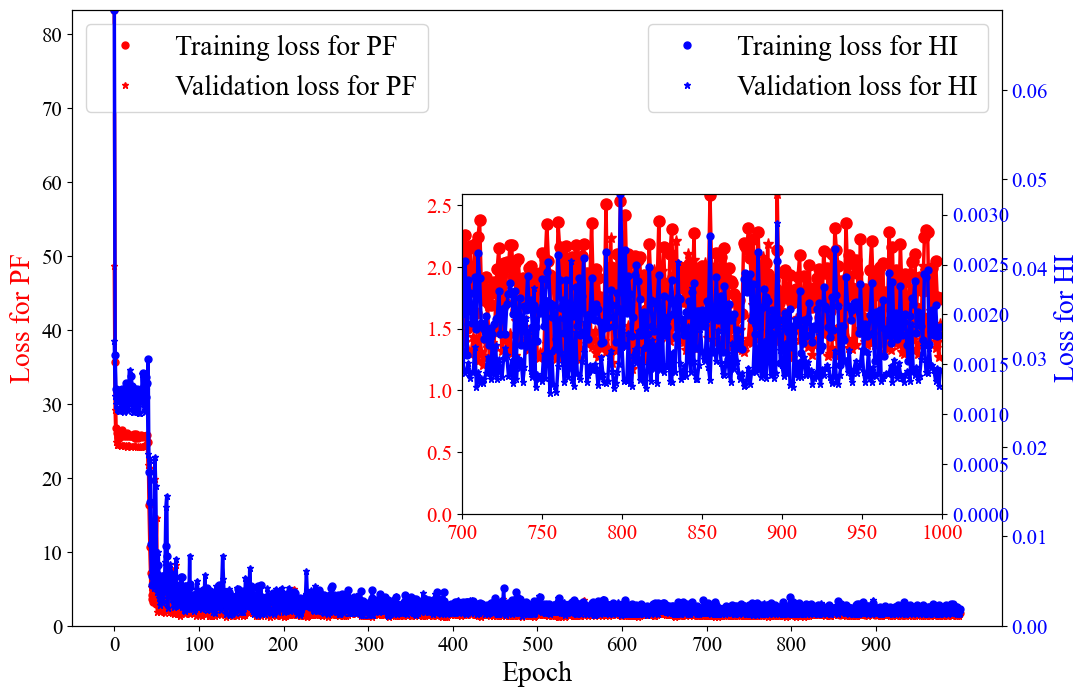

In [22]:
plt.style.use('default')
plt.figure(figsize=(12, 8)) # 创建Figure对象，并指定尺寸
plt.rcParams['font.family'] = ['Times New Roman']

# 设置x轴刻度
epoch = np.arange(0, len(train_loss_force), len(train_loss_force) // 10)
plt.xticks(epoch)

# 创建第一个y轴
ax1 = plt.gca()
ax1.plot(train_loss_force, 'r-', linewidth=2.5)
ax1.plot(train_loss_force, marker='o', markersize=5, color='red', linestyle='None', label='Training loss for PF')
ax1.plot(validation_loss_force, 'r-', linewidth=2.5)
ax1.plot(validation_loss_force, marker='*', markersize=5, color='red', linestyle='None', label='Validation loss for PF')

ax1.set_xlabel('Epoch', fontdict={'weight': 'normal', 'size': 20})
ax1.set_ylabel('Loss for PF', fontdict={'weight': 'normal', 'size': 20}, color='red')

ax1.tick_params(axis='y', labelcolor='red')
ax1.tick_params(axis='both', which='major',labelcolor='black', labelsize=15)

# 添加图例
ax1.legend(loc='upper left', fontsize=20)


max_val = max(
    max(train_loss_force),
    max(validation_loss_force)
)

ax1.set_ylim(0, max_val)

# 创建第二个y轴
ax2 = ax1.twinx()
ax2.plot(train_loss_HI, 'b-', linewidth=2.5)
ax2.plot(train_loss_HI, marker='o', markersize=5, color='blue', linestyle='None', label='Training loss for HI')
ax2.plot(validation_loss_HI, 'b-', linewidth=2.5)
ax2.plot(validation_loss_HI, marker='*', markersize=5, color='blue', linestyle='None', label='Validation loss for HI')

ax2.set_ylabel('Loss for HI', fontdict={'weight': 'normal', 'size': 20}, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='both', which='major',labelcolor='blue', labelsize=15)

max_val = max(
    max(train_loss_HI),
    max(validation_loss_HI)
)

ax2.set_ylim(0, max_val)
ax2.legend(loc='upper right', fontsize=20)

# 创建放大图的子图（inset）
x1 = int(len(train_loss_force)*0.7)
x2 = int(len(train_loss_force))

ax_inset = plt.axes([0.45, 0.25, 0.4, 0.4])  # [left, bottom, width, height]
ax_inset.plot(train_loss_force, 'r-', linewidth=2.5)
ax_inset.plot(train_loss_force, marker='o', markersize=8, color='red', linestyle='None')
ax_inset.plot(validation_loss_force, 'r-', linewidth=2.5)
ax_inset.plot(validation_loss_force, marker='*', markersize=8, color='red', linestyle='None')

max_val = max(
    max(train_loss_force[x1:x2]),
    max(validation_loss_force[x1:x2])
)

ax_inset.set_xlim(x1, x2)
ax_inset.set_ylim(0, max_val)
ax_inset.tick_params(axis='both', which='major',  labelcolor='red',labelsize=15)

ax2 = ax_inset.twinx()

ax2.plot(train_loss_HI, 'b-', linewidth=2.5)
ax2.plot(train_loss_HI, marker='o', markersize=5, color='blue', linestyle='None')
ax2.plot(validation_loss_HI, 'b-', linewidth=2.5)
ax2.plot(validation_loss_HI, marker='*', markersize=5, color='blue', linestyle='None')

max_val = max(
    max(train_loss_HI[x1:x2]),
    max(validation_loss_HI[x1:x2])
)

ax2.set_ylim(0, max_val)

ax2.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='both', which='major', labelsize=15)

# 保存图像
plt.savefig(f'{Save_path}Inverse_problem_Loss.jpg', dpi=600, bbox_inches='tight')
plt.show()